# Backbone network · Persistent path perplexity

# 1. Backbone network

## 0) 설정

In [1]:
from pathlib import Path
from collections import defaultdict
import os, pickle, time

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree

# ── 경로 ─────────────────────────────────────────────────────────────
# 저장소 루트. 다른 위치에서 실행하려면 환경변수 SCISOC_BASE로 덮어쓴다.
BASE = Path(os.environ.get("SCISOC_BASE", ".."))
NET  = BASE / "data" / "processed" / "networks_emb"         # 입력 npz
PROC = BASE / "data" / "processed"   # backbone/ 이 떨어지는 곳
TAB  = BASE / "results" / "tables"    # 결과표
TAB.mkdir(parents=True, exist_ok=True)
for sub in ("backbone",):
    (PROC / sub).mkdir(parents=True, exist_ok=True)

# ── 공통 상수 ────────────────────────────────────────────────────────
YEARS   = list(range(1990, 2024))
SOURCES = ["news", "paper"]
NY      = len(YEARS)
NC      = 29312                      # 필터 어휘 크기

# 1단계 — 백본
DEG_TARGET    = 3        # |E_t| = DEG_TARGET * N_t  → 평균 연결선수 6
ALPHA_REF     = 0.05     # 고정 alpha를 썼다면 어땠을지, 진단용으로만 기록
RETENTION_REF = 0.10     # 잔류율 고정 민감도


## 1) 백본 추출 — disparity filter

`alpha_ij = 1 - (k_i-1)∫₀^{p_ij}(1-x)^{k_i-2}dx = (1-p_ij)^{k_i-1}`

닫힌형을 쓰는 이유는 속도뿐입니다 (`scipy.integrate.quad`로 적분한 값과
오차 1e-15). `k_i = 1`이면 정의되지 않으므로 alpha = 1로 두어 그 끝점에서는
유의해질 수 없게 하고, 반대쪽 끝점 또는 MST 합집합으로만 들어오게 합니다.

In [2]:
(PROC / "backbone").mkdir(parents=True, exist_ok=True)

def edge_alphas(A):
    """Upper-triangle edge list of a symmetric CSR matrix with disparity alphas."""
    U = sp.triu(A, k=1).tocoo()
    i, j, w = U.row.astype(np.int32), U.col.astype(np.int32), U.data.astype(np.float64)

    deg = np.asarray((A != 0).sum(axis=1)).ravel().astype(np.float64)
    stg = np.asarray(A.sum(axis=1)).ravel().astype(np.float64)

    def side(node, w):
        k = deg[node]
        s = stg[node]
        p = np.divide(w, s, out=np.zeros_like(w), where=s > 0)
        a = np.power(np.clip(1.0 - p, 0.0, 1.0), k - 1.0)
        return np.where(k > 1, a, 1.0)          # k = 1 -> undefined, never significant

    a_i, a_j = side(i, w), side(j, w)
    return i, j, w, a_i, a_j, np.minimum(a_i, a_j), deg, stg


def max_spanning_tree_edges(A, n):
    """Edge set (as i*n+j keys, i<j) of the maximum spanning tree of A."""
    U = sp.triu(A, k=1).tocoo()
    wmax = U.data.max()
    T = sp.coo_matrix((wmax + 1.0 - U.data, (U.row, U.col)), shape=A.shape).tocsr()
    M = minimum_spanning_tree(T).tocoo()        # monotone-decreasing transform
    lo = np.minimum(M.row, M.col).astype(np.int64)
    hi = np.maximum(M.row, M.col).astype(np.int64)
    return lo * n + hi


def run_one(source, year):
    A = sp.load_npz(NET / f"{source}_{year}_adj_f.npz").tocsr()
    A.eliminate_zeros()
    n = A.shape[0]

    i, j, w, a_i, a_j, a_min, deg, stg = edge_alphas(A)
    m = len(w)
    n_active = int((deg > 0).sum())
    target = min(DEG_TARGET * n_active, m)

    # rank by alpha_min ascending, ties broken by descending weight
    order = np.lexsort((-w, a_min))
    keep = order[:target]
    implied_alpha = float(a_min[keep[-1]])
    cut_rank_alpha = float(a_min[order[target - 1]]) if target < m else 1.0

    # maximum spanning tree union
    mst_keys = max_spanning_tree_edges(A, n)
    key_all = i.astype(np.int64) * n + j.astype(np.int64)
    in_mst = np.isin(key_all, mst_keys)
    kept_mask = np.zeros(m, dtype=bool)
    kept_mask[keep] = True
    mst_only = in_mst & ~kept_mask
    sel = np.where(kept_mask | mst_only)[0]

    # write edge table
    df = pd.DataFrame({
        "i": i[sel], "j": j[sel],
        "w": np.round(w[sel], 6),
        "alpha_i": a_i[sel], "alpha_j": a_j[sel], "alpha_min": a_min[sel],
        "mst_only": mst_only[sel].astype(np.int8),
    })
    path = PROC / "backbone" / f"{source}_{year}_backbone.csv.gz"
    df.to_csv(path, index=False, float_format="%.6g", compression="gzip")

    # ---- diagnostics on the 3N backbone (without the MST additions) -----
    bi, bj = i[keep], j[keep]
    nodes_bb = np.unique(np.concatenate([bi, bj]))
    B = sp.coo_matrix((np.ones(len(bi)), (bi, bj)), shape=(n, n))
    B = (B + B.T).tocsr()
    ncomp, lab = connected_components(B[nodes_bb][:, nodes_bb], directed=False)
    lcc = np.bincount(lab).max() / len(nodes_bb)

    # with the MST union added
    si, sj = i[sel], j[sel]
    nodes_u = np.unique(np.concatenate([si, sj]))
    U = sp.coo_matrix((np.ones(len(si)), (si, sj)), shape=(n, n))
    U = (U + U.T).tocsr()
    ncomp_u, lab_u = connected_components(U[nodes_u][:, nodes_u], directed=False)
    lcc_u = np.bincount(lab_u).max() / len(nodes_u)

    # ---- diagnostics: what a FIXED alpha would have done ----------------
    n_a05 = int((a_min < ALPHA_REF).sum())

    # ---- sensitivity: fixed 10% retention -------------------------------
    # The two cuts are prefixes of the SAME alpha ordering, so they are nested
    # and their overlap is fixed by the size ratio; what the sensitivity tests
    # is how deep the cut goes, not which edges are eligible.
    t10 = max(int(round(RETENTION_REF * m)), 1)
    inter = min(len(keep), t10)
    jac = inter / (len(keep) + t10 - inter)

    # ---- does the disparity filter differ from plain weight thresholding? -
    top_w = np.argsort(-w, kind="stable")[:target]
    ov = len(np.intersect1d(keep, top_w, assume_unique=False))
    jac_w = ov / (2 * target - ov)

    return df, {
        "source": source, "year": year,
        "n_nodes_active": n_active, "n_edges_total": m,
        "total_weight": float(w.sum()),
        # primary backbone
        "target_edges_3N": int(target),
        "implied_alpha": implied_alpha,
        "retention_rate": target / m,
        "backbone_nodes": int(len(nodes_bb)),
        "node_coverage": len(nodes_bb) / n_active,
        "mean_degree_backbone": 2 * target / len(nodes_bb),
        "weight_share_retained": float(w[keep].sum() / w.sum()),
        "n_components": int(ncomp), "lcc_share": float(lcc),
        # MST union
        "mst_added_edges": int(mst_only.sum()),
        "mst_added_share": float(mst_only.sum() / target),
        "n_components_with_mst": int(ncomp_u), "lcc_share_with_mst": float(lcc_u),
        "union_nodes": int(len(nodes_u)),
        "union_node_coverage": len(nodes_u) / n_active,
        "union_edges": int(len(sel)),
        "mean_degree_union": 2 * len(sel) / len(nodes_u),
        "weight_share_union": float(w[sel].sum() / w.sum()),
        # diagnostics
        "n_edges_alpha_lt_0.05": n_a05,
        "retention_alpha_0.05": n_a05 / m,
        "mean_degree_alpha_0.05": 2 * n_a05 / n_active,
        "sens10_target_edges": t10,
        "sens10_implied_alpha": float(a_min[order[t10 - 1]]),
        "sens10_jaccard_vs_3N": jac,
        "sens10_mean_degree": 2 * t10 / n_active,
        "jaccard_alpha_vs_topweight": jac_w,
    }


def run_stage1_backbone():
    rows = []
    for source in SOURCES:
        for year in YEARS:
            t0 = time.time()
            _, stat = run_one(source, year)
            rows.append(stat)
            print(f"{source} {year}  N={stat['n_nodes_active']:>6}  "
                  f"E={stat['n_edges_total']:>9}  keep={stat['target_edges_3N']:>6}  "
                  f"alpha_t={stat['implied_alpha']:.4g}  "
                  f"cov={stat['node_coverage']:.3f}  "
                  f"mst+={stat['mst_added_edges']:>5}  "
                  f"({time.time()-t0:.1f}s)", flush=True)
    pd.DataFrame(rows).to_csv(TAB / "backbone_summary.csv", index=False)

    subs = pickle.load(open(NET / "global_subjects_filtered.pkl", "rb"))
    pd.DataFrame({"index": np.arange(len(subs)), "subject": subs}).to_csv(
        TAB / "backbone_vocab.csv", index=False)
    print("\ndone ->", PROC)

### 1.1 실행

In [3]:
run_stage1_backbone()

news 1990  N=  2260  E=    40084  keep=  6780  alpha_t=0.203  cov=0.581  mst+= 1041  (0.1s)
news 1991  N=  1538  E=    14386  keep=  4614  alpha_t=0.3682  cov=0.723  mst+=  647  (0.1s)
news 1992  N=  2306  E=    38797  keep=  6918  alpha_t=0.2118  cov=0.576  mst+= 1088  (0.1s)
news 1993  N=  2352  E=    37597  keep=  7056  alpha_t=0.2271  cov=0.614  mst+= 1068  (0.1s)
news 1994  N=  2535  E=    46120  keep=  7605  alpha_t=0.1924  cov=0.591  mst+= 1150  (0.1s)
news 1995  N=  2496  E=    40410  keep=  7488  alpha_t=0.2221  cov=0.604  mst+= 1127  (0.1s)
news 1996  N=  2514  E=    34072  keep=  7542  alpha_t=0.2711  cov=0.640  mst+= 1142  (0.1s)
news 1997  N=  2606  E=    38438  keep=  7818  alpha_t=0.2429  cov=0.646  mst+= 1174  (0.1s)
news 1998  N=  4348  E=   125991  keep= 13044  alpha_t=0.09564  cov=0.535  mst+= 2116  (0.2s)
news 1999  N=  4598  E=   138476  keep= 13794  alpha_t=0.08922  cov=0.528  mst+= 2253  (0.2s)
news 2000  N=  4667  E=   148091  keep= 14001  alpha_t=0.08007  cov=0

### 1.2 검증

산출물이 스스로 주장하는 성질을 다시 확인합니다 — 엣지표 형식, 밀도 성장
아티팩트 제거 여부, 노드 커버리지, 연결성, 잔류 가중치, 그리고 단순
가중치 상위컷과 정말 다른지.

In [4]:
FAIL = []

def check(name, ok, detail=""):
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f"  {detail}" if detail else ""))
    if not ok:
        FAIL.append(name)

print("edge tables are well formed")
S_ = pd.read_csv(TAB / "backbone_summary.csv")
bad = []
for src in ["news", "paper"]:
    for yr in [1990, 2005, 2023]:
        d = pd.read_csv(PROC / "backbone" / f"{src}_{yr}_backbone.csv.gz")
        row = S_[(S_.source == src) & (S_.year == yr)].iloc[0]
        if len(d) != row.union_edges:
            bad.append((src, yr, "row count"))
        if (d.i >= d.j).any():
            bad.append((src, yr, "i<j violated"))
        if d.duplicated(["i", "j"]).any():
            bad.append((src, yr, "duplicate edge"))
        if (d.w <= 0).any():
            bad.append((src, yr, "non-positive weight"))
        if not np.allclose(d.alpha_min, np.minimum(d.alpha_i, d.alpha_j), atol=1e-6):
            bad.append((src, yr, "alpha_min != min"))
        # every non-MST edge must be at or below the implied alpha cut-off
        core = d[d.mst_only == 0]
        if core.alpha_min.max() > row.implied_alpha * (1 + 1e-5) + 1e-12:
            bad.append((src, yr, "alpha above cut-off"))
check("6 spot-checked year files consistent", not bad, str(bad))

print("\n3. the density rule removes the growth artefact")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    r_fixed = np.corrcoef(d.year, d["mean_degree_alpha_0.05"])[0, 1]
    r_ours = np.corrcoef(d.year, d["mean_degree_union"])[0, 1]
    g_fixed = d["mean_degree_alpha_0.05"].iloc[-1] / d["mean_degree_alpha_0.05"].iloc[0]
    g_ours = d["mean_degree_union"].iloc[-1] / d["mean_degree_union"].iloc[0]
    print(f"  {src:<6} mean degree vs year:  fixed alpha=0.05  r={r_fixed:+.3f} "
          f"({g_fixed:.2f}x)   |E|=3N + MST  r={r_ours:+.3f} ({g_ours:.2f}x)")
    check(f"{src}: backbone mean degree flat across the period",
          abs(g_ours - 1) < 0.10 and g_fixed > 2.0,
          f"ours {g_ours:.2f}x vs fixed-alpha {g_fixed:.2f}x")

print("\n4. node coverage and connectivity")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    check(f"{src}: every active concept is in the backbone",
          bool((d.union_node_coverage > 0.9999).all()),
          f"min={d.union_node_coverage.min():.4f}")
    check(f"{src}: largest component covers >95% of the backbone",
          bool((d.lcc_share_with_mst > 0.95).all()),
          f"min={d.lcc_share_with_mst.min():.4f}")

print("\n5. weight retained is stable across the period")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    dens = d.n_edges_total / d.n_nodes_active
    r = np.corrcoef(dens, d.weight_share_union)[0, 1]
    print(f"  {src:<6} weight share retained {d.weight_share_union.min():.3f}"
          f"-{d.weight_share_union.max():.3f} (sd {d.weight_share_union.std():.3f}), "
          f"corr with that year's E/N = {r:+.2f}")

print("\n6. the filter is not equivalent to weight thresholding")
for src in ["news", "paper"]:
    d = S_[S_.source == src]
    print(f"  {src:<6} Jaccard(alpha-cut, top-weight cut) = "
          f"{d.jaccard_alpha_vs_topweight.min():.3f}-{d.jaccard_alpha_vs_topweight.max():.3f}")

print("\n" + ("ALL CHECKS PASSED" if not FAIL else f"FAILURES: {FAIL}"))

edge tables are well formed
  [PASS] 6 spot-checked year files consistent  []

3. the density rule removes the growth artefact
  news   mean degree vs year:  fixed alpha=0.05  r=+0.884 (4.33x)   |E|=3N + MST  r=+0.665 (1.01x)
  [PASS] news: backbone mean degree flat across the period  ours 1.01x vs fixed-alpha 4.33x
  paper  mean degree vs year:  fixed alpha=0.05  r=+0.987 (4.55x)   |E|=3N + MST  r=+0.945 (1.03x)
  [PASS] paper: backbone mean degree flat across the period  ours 1.03x vs fixed-alpha 4.55x

4. node coverage and connectivity
  [PASS] news: every active concept is in the backbone  min=1.0000
  [PASS] news: largest component covers >95% of the backbone  min=0.9883
  [PASS] paper: every active concept is in the backbone  min=1.0000
  [PASS] paper: largest component covers >95% of the backbone  min=0.9998

5. weight retained is stable across the period
  news   weight share retained 0.494-0.711 (sd 0.041), corr with that year's E/N = -0.62
  paper  weight share retained 0.527

### 1.3 참조 구현과 대조 (선택)

`aekpalakorn/python-backbone-network`를 받아 그 코드로 같은 연도의 백본을
뽑고 같은 엣지 수에서 비교합니다. alpha 값 자체는 동일하고, 차이는 그
저장소의 무방향 분기가 같은 엣지에 alpha를 덮어써서 OR 규칙이 아니라
*나중에 처리된 끝점*의 값을 남기는 데서만 옵니다.

In [5]:
# !git clone --depth 1 https://github.com/aekpalakorn/python-backbone-network /tmp/pbn
# (py2 print 문이 있는 __main__ 블록을 떼고 임포트)
import networkx as nx
from scipy import integrate

def _load_reference():
    src = Path("/tmp/pbn/backbone.py").read_text().split("if __name__ == '__main__':")[0]
    ns = {}
    exec(compile(src, "ref_backbone", "exec"), ns)
    return ns["disparity_filter"]

def compare_with_reference(source, year):
    ref_disparity_filter = _load_reference()
    A = sp.load_npz(NET / f"{source}_{year}_adj_f.npz").tocsr(); A.eliminate_zeros()
    i, j, w, a_i, a_j, a_min, deg, _ = edge_alphas(A)
    n_active = int((deg > 0).sum())
    target = min(DEG_TARGET * n_active, len(w))
    ours = set(map(tuple, np.c_[i, j][np.lexsort((-w, a_min))[:target]]))

    G = nx.Graph()
    U = sp.triu(A, k=1).tocoo()
    G.add_weighted_edges_from(zip(U.row.tolist(), U.col.tolist(), U.data.tolist()))
    B = ref_disparity_filter(G)
    el = sorted(B.edges(data=True), key=lambda e: (e[2]["alpha"], -e[2]["weight"]))
    repo = set((min(u, v), max(u, v)) for u, v, _ in el[:target])
    inter = len(ours & repo)
    print(f"{source} {year}: backbone {target} edges, 공통 {inter} = {inter/target:.1%}, "
          f"Jaccard {inter/(2*target-inter):.4f}")

def check_closed_form_vs_quad(source="news", year=1990, n_hub=400):
    """닫힌형 alpha가 Eq.(2)의 수치적분과 같은지 실데이터로 전수 확인."""
    A = sp.load_npz(NET / f"{source}_{year}_adj_f.npz").tocsr()
    deg = np.asarray((A != 0).sum(1)).ravel()
    S = A[np.argsort(-deg)[:n_hub]][:, np.argsort(-deg)[:n_hub]].tocsr()
    S.eliminate_zeros()
    i, j, w, a_i, a_j, _, _, _ = edge_alphas(S)
    k = np.asarray((S != 0).sum(1)).ravel(); s = np.asarray(S.sum(1)).ravel()
    d = []
    for node, ww, a in ((i, w, a_i), (j, w, a_j)):
        for nd, x, av in zip(node, ww, a):
            if k[nd] <= 1:
                continue
            q = 1 - (k[nd]-1) * integrate.quad(lambda t: (1-t)**(k[nd]-2), 0, x/s[nd])[0]
            d.append(abs(av - q))
    print(f"닫힌형 vs quad: 최대 오차 {max(d):.3e}  (끝점 {len(d):,}개)")

# check_closed_form_vs_quad()
# for y in (1990, 2005, 2023): compare_with_reference("news", y)


## 2) 엣지 지속성

엣지가 그 해 **백본 본체**(`mst_only == 0`; MST 추가분은 연결성 보수이지
유의한 엣지가 아니므로 제외)에 있으면 그 해에 존재한 것으로 봅니다.
엣지마다 총 등장연수와 **최장 연속 구간**을 기록합니다.

In [6]:
def presence_matrix(source, include_mst=False):
    """dict edge_key -> bool vector over the 34 years, plus the weight matrix."""
    pres = {}
    wts = {}
    for yi, y in enumerate(YEARS):
        d = pd.read_csv(PROC / "backbone" / f"{source}_{y}_backbone.csv.gz")
        if not include_mst:
            d = d[d.mst_only == 0]
        keys = d.i.values.astype(np.int64) * 29312 + d.j.values.astype(np.int64)
        for k, w in zip(keys, d.w.values):
            v = pres.get(k)
            if v is None:
                v = np.zeros(NY, dtype=bool)
                pres[k] = v
                wts[k] = np.zeros(NY, dtype=np.float32)
            v[yi] = True
            wts[k][yi] = w
    return pres, wts


def runs(v):
    """(longest consecutive run, start index of that run)."""
    best = cur = 0
    best_s = s = 0
    for t, x in enumerate(v):
        if x:
            if cur == 0:
                s = t
            cur += 1
            if cur > best:
                best, best_s = cur, s
        else:
            cur = 0
    return best, best_s


def edge_table(source, include_mst=False):
    pres, wts = presence_matrix(source, include_mst)
    rows = []
    for k, v in pres.items():
        r, s = runs(v)
        rows.append((k // 29312, k % 29312, int(v.sum()), r,
                     YEARS[s], YEARS[s + r - 1],
                     float(wts[k][v].mean()), float(wts[k][v].min())))
    df = pd.DataFrame(rows, columns=["i", "j", "years_present", "longest_run",
                                     "run_start", "run_end", "w_mean", "w_min"])
    return df.sort_values(["longest_run", "years_present", "w_mean"],
                          ascending=False).reset_index(drop=True)



def run_stage2_persistence():
    summary = []
    for source in ["news", "paper"]:
        df = edge_table(source)
        df.to_csv(TAB / f"{source}_edge_persistence.csv.gz",
                  index=False, float_format="%.6g", compression="gzip")
        print(f"\n{source}: {len(df):,} distinct backbone edges over 34 years")
        prof = df.longest_run.value_counts().sort_index(ascending=False)
        print("  longest consecutive run -> n edges (top):")
        for r in [34, 30, 25, 20, 15, 10, 5, 1]:
            n = int((df.longest_run >= r).sum())
            print(f"    >= {r:>2} years : {n:>8,}")
            summary.append({"source": source, "min_run": r, "n_edges": n})
    pd.DataFrame(summary).to_csv(TAB / "persistence_profile.csv", index=False)

In [7]:
run_stage2_persistence()


news: 160,112 distinct backbone edges over 34 years
  longest consecutive run -> n edges (top):
    >= 34 years :      163
    >= 30 years :      393
    >= 25 years :    1,495
    >= 20 years :    2,155
    >= 15 years :    3,302
    >= 10 years :    6,361
    >=  5 years :   16,367
    >=  1 years :  160,112

paper: 196,246 distinct backbone edges over 34 years
  longest consecutive run -> n edges (top):
    >= 34 years :    9,674
    >= 30 years :   12,422
    >= 25 years :   16,799
    >= 20 years :   22,997
    >= 15 years :   29,570
    >= 10 years :   38,297
    >=  5 years :   56,797
    >=  1 years :  196,246


# 2. Persistent path sequence & sequence perplexity

위에서 만든 **엣지별 지속 구간**(`results/tables/{news,paper}_edge_persistence.csv.gz`)을
받아, 여기서부터는 **persistent path**를 뽑아 임베딩으로 연도별 perplexity를 잰다.

**persistent path**란 `v₁ – v₂ – … – v_K` 사슬 중에서 **K−1개 엣지가 전부 동시에** 백본에
남아 있는 연속 구간이 `L`년 이상인 것을 말한다. 엣지 하나하나가 오래간 것이 아니라
사슬 전체가 같은 기간 동안 함께 유지되어야 한다.

## 1) Persistent path perplexity with dynamic graph embedding

백본에서 **L년 이상 연속 지속된 개념 시퀀스**를 뽑아, 기존 LexicalDySAT 임베딩으로
**연도별 perplexity**를 계산한다.

### 설계

| 항목 | 값 |
|---|---|
| 지속 기준 | 시퀀스의 모든 엣지가 **동시에** 백본에 있는 연속 구간 ≥ `L`년 |
| 시퀀스 길이 | `K` 노드 (스텝 `K−1`개) |
| 조건부 | **앞의 것만** (autoregressive) → 연쇄법칙 성립 → pseudo 아닌 **진짜 perplexity** |
| 문맥 벡터 | 앞선 노드 좌표의 감쇠 가중평균 (`LAM`) — 최근일수록 큰 가중치 |
| 확률 | `softmax( c · z_u )`, 후보 = 그 해 활성 개념 전부, 이미 지나온 노드는 제외 |
| 방향 | 무방향 네트워크이므로 정·역 양방향 평균 |
| 임베딩 | 기존 `embeddings/{src}_embeddings.pt` `[34, 29312, 32]` — **재학습 없음** |

### 지표 두 개

- **PP** = `exp(−평균 log p)` — "스텝당 몇 지선다만큼 헷갈렸나"
- **순위** = 진짜 다음 개념이 후보 중 몇 등인가 — 임베딩 눈금 보정에 영향받지 않음

## 0) 설정

In [8]:
import gzip, csv, os, zipfile, collections
import numpy as np

# 이 절이 읽는 입력 (BASE·YEARS·SOURCES·NC 는 노트북 첫 셀에서 정의):
#   (아래 파일은 저장소에 포함되지 않는다 — README 참조)
#     {BASE}/data/processed/embeddings/{news,paper}_embeddings.pt            [34, 29312, 32], 각 127MB
#     {BASE}/data/processed/networks_emb/{news,paper}_{1990..2023}_adj_f.npz  연도별 공출현 행렬
#     {BASE}/results/tables/backbone_vocab.csv                                개념 인덱스 -> 이름
#     {BASE}/results/tables/{news,paper}_edge_persistence.csv.gz              백본 엣지 지속 구간
SEQ   = os.path.join(BASE, "results", "sequences")   # 표·중간산출물
FIG   = os.path.join(BASE, "results", "figures")     # 그림
os.makedirs(FIG, exist_ok=True)
os.makedirs(SEQ, exist_ok=True)

L      = 20        # 지속 기준 (년)
KS     = [6, 8]    # 시퀀스 길이
NSEQ   = 2000      # 코퍼스·K당 시퀀스 수
LAM    = 0.5       # 문맥 감쇠 (1.0 = 단순평균, 작을수록 최근 강조)
N_NODE = NC                         # 필터 어휘 크기 (위에서 정의)

print(BASE, "\nL =", L, " K =", KS, " NSEQ =", NSEQ, " LAM =", LAM)

.. 
L = 20  K = [6, 8]  NSEQ = 2000  LAM = 0.5


## 1) 임베딩 읽기

`.pt`는 torch 없이도 읽을 수 있다 — zip 안에 float32 원시 바이트가 통째로 들어 있다.

In [9]:
def load_emb(src, shape=(34, N_NODE, 32)):
    """전체 임베딩이 있으면 그것을, 없으면 저장소에 포함된 샘플을 읽는다.

    전체 (embeddings/{src}_embeddings.pt, 122MB) — 34개 연도. torch 없이
    zip으로 열어 float32 원시 바이트를 직접 읽는다.
    샘플 (embeddings/{src}_embeddings_sample.npy, 11MB) — 1995·2010·2023년만.
    """
    full = f"{BASE}/data/processed/embeddings/{src}_embeddings.pt"
    if os.path.exists(full):
        z = zipfile.ZipFile(full)
        name = [i.filename for i in z.infolist() if i.filename.endswith("data/0")][0]
        return np.frombuffer(z.read(name), dtype="<f4").reshape(shape)

    samp = f"{BASE}/data/processed/embeddings/{src}_embeddings_sample.npy"
    if os.path.exists(samp):
        E = np.load(samp)
        print(f"⚠ 전체 임베딩이 없어 샘플을 사용합니다 ({src}): {E.shape}"
              " — 1995·2010·2023년만. 아래 분석은 전체 34년을 전제하므로 결과가 다릅니다.")
        return E

    raise FileNotFoundError(
        f"임베딩이 없습니다.\n  전체: {full}\n  샘플: {samp}\n"
        "README의 '데이터' 절을 참고해 embeddings/ 에 파일을 넣으세요.")

# 확인 — 저장소에 news 샘플이 있으므로 news 로 점검한다
_e = load_emb("news")
print(_e.shape, _e.dtype, "노드 norm 평균 =",
      round(float(np.linalg.norm(_e[-1], axis=1).mean()), 3))
del _e

(34, 29312, 32) float32 노드 norm 평균 = 0.589


## 2) 지속 백본 네트워크

`{src}_edge_persistence.csv.gz`의 `longest_run ≥ L`인 엣지만 남긴다.
각 엣지의 최장 연속 구간 `[run_start, run_end]`도 함께 들고 있다가,
시퀀스의 지속 구간 = **모든 엣지 구간의 교집합**으로 계산한다.

In [10]:
def persistent_graph(src, L=L):
    E, adj = {}, collections.defaultdict(list)
    with gzip.open(f"{BASE}/results/tables/{src}_edge_persistence.csv.gz", "rt") as fh:
        for r in csv.DictReader(fh):
            if int(r["longest_run"]) >= L:
                i, j = int(r["i"]), int(r["j"])
                E[(min(i,j), max(i,j))] = (int(r["run_start"]), int(r["run_end"]))
                adj[i].append(j); adj[j].append(i)
    return E, {k: np.array(v) for k, v in adj.items()}

for src in SOURCES:
    E, adj = persistent_graph(src)
    deg = np.array([len(v) for v in adj.values()])
    print(f"{src:6} L>={L}: 엣지 {len(E):>7,}  개념 {len(adj):>6,}  "
          f"연결선수 중앙값 {int(np.median(deg))} 평균 {deg.mean():.1f} 최대 {deg.max()}")

news   L>=20: 엣지   2,155  개념    863  연결선수 중앙값 1 평균 5.0 최대 774
paper  L>=20: 엣지  22,997  개념  4,379  연결선수 중앙값 3 평균 10.5 최대 1621


### 허브 점검

랜덤워크 표본은 연결선수가 큰 노드로 편향된다. 어떤 개념이 허브인지 먼저 본다.

In [11]:
vocab = {}
with open(f"{BASE}/results/tables/backbone_vocab.csv") as f:
    rd = csv.DictReader(f); ks = rd.fieldnames
    for r in rd: vocab[int(r[ks[0]])] = r[ks[1]]

for src in SOURCES:
    E, adj = persistent_graph(src)
    top = sorted(((len(v), k) for k, v in adj.items()), reverse=True)[:6]
    print(f"--- {src}"); [print(f"   {d:5d}  {vocab.get(n, n)}") for d, n in top]

--- news
     774  automation
     244  software
      88  customer services
      82  alliances
      79  information systems
      51  marketing
--- paper
    1621  control (management)
    1501  image (mathematics)
     833  perspective (graphical)
     744  pattern recognition (psychology)
     741  process (computing)
     681  class (philosophy)


## 3) 시퀀스 표본 추출

백본 위 랜덤워크 → 단순경로(재방문 금지) → 구간 교집합이 `L`년 이상인 것만 채택.

> ⚠️ 랜덤워크는 **균일 표본이 아니다**. 허브 쪽으로 편향된다.

In [12]:
def sample_sequences(src, K, n=NSEQ, L=L, seed=0):
    E, adj = persistent_graph(src, L)
    rng = np.random.default_rng(seed)
    nodes = np.array(list(adj))
    deg   = np.array([len(adj[x]) for x in nodes])
    p     = deg / deg.sum()
    out, tries = {}, 0
    while len(out) < n and tries < n * 4000:
        tries += 1
        s = int(rng.choice(nodes, p=p)); path = [s]; seen = {s}; lo, hi = 1990, 2023
        for _ in range(K - 1):
            nb  = adj[path[-1]]
            nxt = int(nb[rng.integers(len(nb))])
            if nxt in seen: break
            a, b = E[(min(path[-1], nxt), max(path[-1], nxt))]
            lo, hi = max(lo, a), min(hi, b)
            if hi - lo + 1 < L: break
            path.append(nxt); seen.add(nxt)
        if len(path) == K:
            key = tuple(path) if path[0] < path[-1] else tuple(reversed(path))
            out.setdefault(key, (lo, hi))
    P   = np.array([list(k) for k in out])
    win = np.array([v for v in out.values()])
    return P, win, tries

# 예시 확인
P, win, tries = sample_sequences("paper", 6, n=200)
print(f"200개 뽑는 데 워크 {tries}회 (성립률 {200/tries:.1%})")
for row, w in list(zip(P, win))[:3]:
    print(f"  [{w[0]}-{w[1]}]  " + " → ".join(vocab.get(int(x), str(x)) for x in row))

200개 뽑는 데 워크 444회 (성립률 45.0%)
  [1990-2023]  intervention (counseling) → conceptualization → operationalization → variety (cybernetics) → state (computer science) → process (computing)
  [2003-2023]  nonparametric statistics → kernel (algebra) → bayesian probability → identification (biology) → word (group theory) → recall
  [2003-2023]  radiation therapy → computed tomography → contrast (vision) → politics → word (group theory) → sentence


## 4) 한 해의 perplexity

핵심 함수. 스텝 `k`마다:

1. **문맥** `c_k` = 앞선 노드 `v_1..v_k` 좌표의 감쇠 가중평균
2. **점수** = `c_k · z_u` (내적) — 학습에 쓴 연산 그대로
3. **확률** = 그 해 활성 개념 전체에 softmax, 이미 지나온 노드는 `-inf`
4. 진짜 `v_{k+1}`의 log 확률과 **순위**를 기록

정·역 양방향을 평균한다.

In [13]:
def year_scores(src, K, t, Emb, P, LAM=LAM):
    yr = 1990 + t
    z  = np.load(f"{BASE}/data/processed/networks_emb/{src}_{yr}_adj_f.npz", allow_pickle=True)
    deg = np.diff(z["indptr"]); act = np.where(deg > 0)[0]; nA = len(act)
    remap = -np.ones(N_NODE, dtype=np.int64); remap[act] = np.arange(nA)

    Z  = Emb[t]
    Za = np.ascontiguousarray(Z[act])
    n  = len(P)
    lp = np.zeros((n, K - 1)); rk = np.zeros((n, K - 1))

    for d, seq in enumerate([P, P[:, ::-1]]):          # 정방향 / 역방향
        R = remap[seq]
        for k in range(1, K):
            w = LAM ** np.arange(k - 1, -1, -1); w = w / w.sum()   # 오래된 것 → 최근
            C = (Z[seq[:, :k]] * w[None, :, None]).sum(1)          # 문맥 [n, 32]
            tgt = R[:, k]
            a_lp = np.full(n, np.nan); a_rk = np.full(n, np.nan)
            for s0 in range(0, n, 1000):                            # 메모리 위해 분할
                s1 = min(s0 + 1000, n); b = s1 - s0
                Lg = C[s0:s1] @ Za.T                                # 내적 [b, nA]
                pr = R[s0:s1, :k]                                   # 지나온 노드 제외
                rows = np.repeat(np.arange(b), k); cols = pr.ravel(); m = cols >= 0
                Lg[rows[m], cols[m]] = -np.inf
                mx  = Lg.max(1, keepdims=True)
                lse = mx[:, 0] + np.log(np.exp(Lg - mx).sum(1))     # log Σ exp
                tt  = tgt[s0:s1]; ok = tt >= 0; ti = np.clip(tt, 0, nA - 1)
                lg_t = Lg[np.arange(b), ti]
                a_lp[s0:s1] = np.where(ok, lg_t - lse, np.nan)      # log p
                a_rk[s0:s1] = np.where(ok, (Lg > lg_t[:, None]).sum(1) + 1, np.nan)
            if d == 0: lp[:, k-1], rk[:, k-1] = a_lp, a_rk
            else:      lp[:, k-1] = (lp[:, k-1] + a_lp) / 2; rk[:, k-1] = (rk[:, k-1] + a_rk) / 2

    pp  = np.exp(-lp.mean(1))          # perplexity
    rkm = rk.mean(1)                   # 평균 순위
    allact = (remap[P] >= 0).all(1)    # 그 해 모든 노드가 활성인가
    return pp, rkm, nA, allact

## 5) 전체 실행

코퍼스 2개 × K 2개 × 34년. 노트북 전체로 3–5분.

In [14]:
import time
records = []
for src in SOURCES:
    Emb = load_emb(src)
    for K in KS:
        P, win, _ = sample_sequences(src, K, NSEQ)
        np.savez(f"{SEQ}/seqs_{src}_K{K}.npz", P=P, win=win)
        t0 = time.time()
        for t in range(len(YEARS)):
            pp, rk, nA, allact = year_scores(src, K, t, Emb, P)
            for i in range(len(P)):
                records.append((src, K, YEARS[t], i, pp[i], rk[i], rk[i]/nA, nA,
                                int(allact[i]), int(win[i,0]), int(win[i,1])))
        print(f"{src} K={K}  완료 ({time.time()-t0:.0f}s)   "
              f"1995 PP중앙값 {np.nanmedian([r[4] for r in records if r[0]==src and r[1]==K and r[2]==1995]):.0f}")
    del Emb

import pandas as pd
df = pd.DataFrame(records, columns=["source","K","year","seq_id","pp","rank","rank_norm",
                                    "n_active","all_active","win_start","win_end"])
df.to_csv(f"{SEQ}/seq_all.csv", index=False)
print(df.shape)

news K=6  완료 (23s)   1995 PP중앙값 1016
news K=8  완료 (35s)   1995 PP중앙값 1022
paper K=6  완료 (79s)   1995 PP중앙값 1684
paper K=8  완료 (107s)   1995 PP중앙값 1537
(272000, 11)


## 6) 연도별 요약

In [15]:
summ = (df.groupby(["source","K","year"])
          .agg(pp_median=("pp","median"), rank_median=("rank","median"),
               rank_norm_median=("rank_norm","median"), n_active=("n_active","first"),
               rank_q25=("rank", lambda s: s.quantile(.25)),
               rank_q75=("rank", lambda s: s.quantile(.75)))
          .reset_index())
summ.to_csv(f"{SEQ}/seq_summary.csv", index=False)

piv = summ.pivot_table(index="year", columns=["source","K"], values="rank_norm_median") * 100
piv.round(2).loc[[1990,1993,1995,1998,2000,2005,2010,2015,2020,2023]]

source   news        paper      
K           6      8     6     8
year                            
1990    21.39  21.69  8.30  8.29
1993    12.06  12.19  4.22  4.30
1995    10.69  11.09  3.69  3.78
1998     5.23   5.28  3.29  3.38
2000     3.35   3.34  2.97  3.02
2005     2.23   2.21  2.55  2.50
2010     1.81   1.79  2.26  2.23
2015     1.56   1.61  2.19  2.13
2020     1.22   1.26  2.10  2.09
2023     1.16   1.17  2.10  2.08

## 7) 기울기 — 언제 평탄해지는가

로그 스케일 기울기(%/년)를 전기·후기로 나눠 비교한다.

- **1990–1992 제외**: causal mask 때문에 초기 연도는 temporal attention이 참조할 과거가 거의 없어
  표현이 부실하다. 개념 신규성이 아니라 모형 warm-up이다.
- **news는 1998 이후만**: 1998년에 활성 개념이 2,606 → 4,348로 뛴다 (코퍼스 수집 변화).

In [16]:
def logslope(sub, col, a, b):
    m = (sub.year >= a) & (sub.year <= b)
    return np.polyfit(sub.year[m], np.log(sub[col][m]), 1)[0] * 100

SPLIT = 2008
print(f"{'':22}{'전기':>9}{'후기':>9}   평탄화")
for src, start in [("news", 1998), ("paper", 1993)]:
    for K in KS:
        sub = summ[(summ.source==src) & (summ.K==K)]
        for col, lab in [("pp_median","PP"), ("rank_median","순위"), ("rank_norm_median","순위%")]:
            s1 = logslope(sub, col, start, SPLIT); s2 = logslope(sub, col, SPLIT+1, 2023)
            print(f"{src:6} K={K} {lab:5}{s1:8.2f}%{s2:8.2f}%   {s1/s2:5.1f}배")
    print()

for src in SOURCES:
    sub = summ[(summ.source==src)&(summ.K==KS[0])].set_index("year")
    print(f"{src} 활성개념 2009→2023: {sub.n_active[2009]:,} → {sub.n_active[2023]:,} "
          f"({sub.n_active[2023]/sub.n_active[2009]-1:+.1%})")

                             전기       후기   평탄화
news   K=6 PP      -2.78%   -0.10%    27.8배
news   K=6 순위      -5.99%   -1.29%     4.6배
news   K=6 순위%     -9.18%   -3.51%     2.6배
news   K=8 PP      -2.95%   -0.13%    22.7배
news   K=8 순위      -6.19%   -1.10%     5.6배
news   K=8 순위%     -9.38%   -3.32%     2.8배

paper  K=6 PP      -3.42%   -0.64%     5.3배
paper  K=6 순위      -1.88%   -0.31%     6.1배
paper  K=6 순위%     -3.84%   -0.58%     6.6배
paper  K=8 PP      -3.33%   -0.50%     6.7배
paper  K=8 순위      -2.18%   -0.23%     9.4배
paper  K=8 순위%     -4.14%   -0.51%     8.2배

news 활성개념 2009→2023: 6,004 → 7,560 (+25.9%)
paper 활성개념 2009→2023: 17,403 → 18,111 (+4.1%)


## 8) Figures

네 개를 만든다. 파일은 `seq_perplexity/fig*.png`로 저장된다.

| | 무엇을 보여주나 |
|---|---|
| Fig 1 | 지속 구조의 비대칭 — 임계 L별 잔존 엣지, 길이 K별 시퀀스 수율 |
| Fig 2 | 주 결과 — 연도별 perplexity·순위·정규화 순위 |
| Fig 3 | 평탄화 — 전기/후기 로그 기울기 |
| Fig 4 | 시퀀스 간 산포와 연간 이동량 |

색은 `dataviz` 기준 팔레트의 categorical 1·2번(blue/orange)이고,
코퍼스가 색, 길이 K가 선 종류를 맡는다 (색을 4개 쓰지 않음).

### 8.0 스타일과 보조 자료

In [17]:
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PAPER="#2a78d6"; NEWS="#eb6834"; INK="#0b0b0b"; INK2="#52514e"; MUTED="#8a8983"
SURF="#fcfcfb"; GRIDC="#e3e2dd"; BAND="#f0efec"
CLR={"news":NEWS,"paper":PAPER}
plt.rcParams.update({"figure.facecolor":SURF,"axes.facecolor":SURF,"savefig.facecolor":SURF,
    "axes.edgecolor":GRIDC,"axes.labelcolor":INK2,"xtick.color":INK2,"ytick.color":INK2,
    "text.color":INK,"font.size":9,"axes.titlesize":10,"axes.titleweight":"bold",
    "axes.titlecolor":INK,"axes.spines.top":False,"axes.spines.right":False,
    "grid.color":GRIDC,"grid.linewidth":.7,"legend.frameon":False,"font.family":"DejaVu Sans"})
def tidy(ax,ygrid=True):
    ax.grid(True,axis="both" if ygrid else "x",alpha=.9,lw=.7); ax.set_axisbelow(True)
    ax.tick_params(length=0)

def S(src,K): return summ[(summ.source==src)&(summ.K==K)].sort_values("year")

# fig1b에 쓸 길이별 수율
rows=[]
for src in SOURCES:
    E,adj = persistent_graph(src)
    rng=np.random.default_rng(0); nd=np.array(list(adj))
    dg=np.array([len(adj[x]) for x in nd]); p=dg/dg.sum()
    for K in [4,5,6,8,10,12,15]:
        NS=8000; ok=0
        for st in rng.choice(nd,size=NS,p=p):
            path=[int(st)]; seen={int(st)}; lo,hi=1990,2023
            for _ in range(K-1):
                nb=adj[path[-1]]; nxt=int(nb[rng.integers(len(nb))])
                if nxt in seen: break
                a,b=E[(min(path[-1],nxt),max(path[-1],nxt))]
                lo,hi=max(lo,a),min(hi,b)
                if hi-lo+1<L: break
                path.append(nxt); seen.add(nxt)
            if len(path)==K: ok+=1
        rows.append((src,K,ok/NS))
yield_table=pd.DataFrame(rows,columns=["source","K","rate"])
yield_table.to_csv(f"{SEQ}/yield_by_K.csv",index=False)
yield_table.pivot_table(index="K",columns="source",values="rate").round(3)

source,news,paper
K,,
4,0.511,0.735
5,0.369,0.597
6,0.228,0.486
8,0.102,0.297
10,0.034,0.177
12,0.010,0.106
15,0.002,0.039


### 8.1 Figure 1

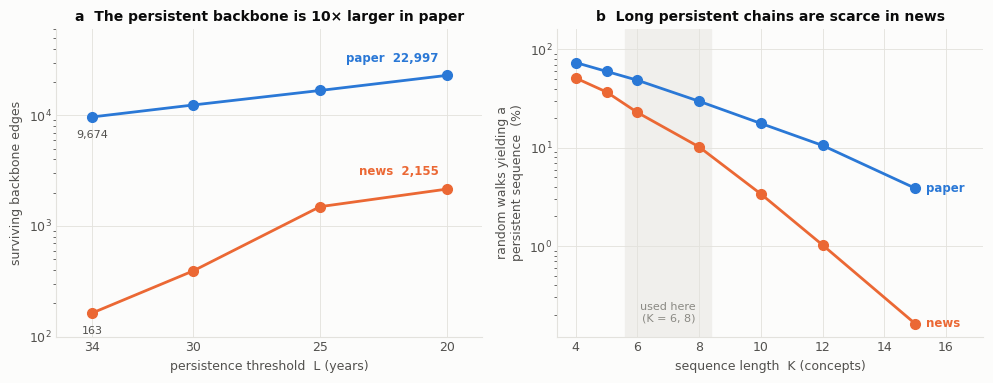

In [18]:
# ============ Fig 1 — persistent structure ============
def edge_count(src,L):
    n=0
    with gzip.open(f"{BASE}/results/tables/{src}_edge_persistence.csv.gz",'rt') as fh:
        for r in csv.DictReader(fh):
            if int(r['longest_run'])>=L: n+=1
    return n
Ls=[20,25,30,34]
edges={s:[edge_count(s,l) for l in Ls] for s in ["news","paper"]}
yK = yield_table

fig,axes=plt.subplots(1,2,figsize=(10.0,3.9))
ax=axes[0]
for s in ["news","paper"]:
    ax.plot(Ls,edges[s],color=CLR[s],lw=2,marker="o",ms=7,clip_on=False,zorder=3)
    ax.annotate(f"{s}  {edges[s][0]:,}",(Ls[0],edges[s][0]),xytext=(-6,10),
                textcoords="offset points",fontsize=8.5,color=CLR[s],fontweight="bold",ha="right")
    ax.annotate(f"{edges[s][-1]:,}",(Ls[-1],edges[s][-1]),xytext=(0,-15),
                textcoords="offset points",fontsize=8,color=INK2,ha="center")
ax.set_yscale("log"); ax.set_xticks(Ls); ax.set_xlim(35.4,18.6)
ax.set_ylim(100,60000)
ax.set_xlabel("persistence threshold  L (years)"); ax.set_ylabel("surviving backbone edges")
ax.set_title("a  The persistent backbone is 10× larger in paper"); tidy(ax)

ax=axes[1]
ax.axvspan(5.6,8.4,color=BAND,zorder=0)
for s in ["news","paper"]:
    d=yK[yK.source==s]
    ax.plot(d.K,d.rate*100,color=CLR[s],lw=2,marker="o",ms=7,clip_on=False,zorder=3)
    ax.annotate(s,(d.K.iloc[-1],d.rate.iloc[-1]*100),xytext=(8,0),textcoords="offset points",
                fontsize=8.5,color=CLR[s],fontweight="bold",va="center")
ax.set_yscale("log"); ax.set_xlim(3.4,17.2); ax.set_ylim(.12,160)
ax.text(7,.17,"used here\n(K = 6, 8)",fontsize=8,color=MUTED,ha="center")
ax.set_xlabel("sequence length  K (concepts)")
ax.set_ylabel("random walks yielding a\npersistent sequence  (%)")
ax.set_title("b  Long persistent chains are scarce in news"); tidy(ax)
plt.tight_layout(); plt.savefig(f"{FIG}/fig1_structure.png",dpi=200); plt.show()

### 8.2 Figure 2

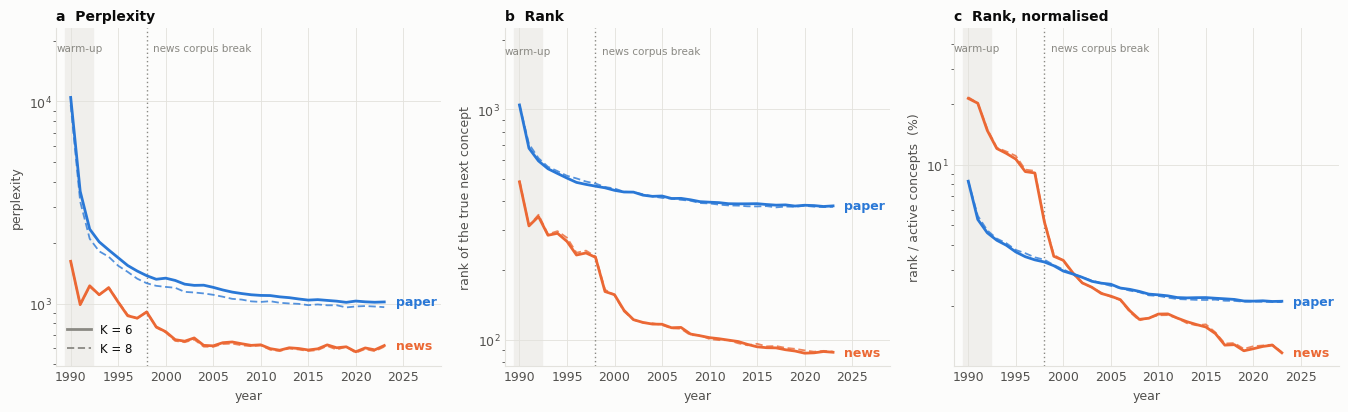

In [19]:
# ============ Fig 2 — trajectories ============
fig,axes=plt.subplots(1,3,figsize=(13.6,4.2),sharex=True)
panels=[("pp_median","perplexity","a  Perplexity"),
        ("rank_median","rank of the true next concept","b  Rank"),
        ("rank_norm_median","rank / active concepts  (%)","c  Rank, normalised")]
for pi,(ax,(col,ylab,title)) in enumerate(zip(axes,panels)):
    ax.axvspan(1989.4,1992.4,color=BAND,zorder=0)
    ax.axvline(1998,color=MUTED,ls=(0,(1,2)),lw=1,zorder=1)
    for s in ["news","paper"]:
        for K,ls,lw,al in [(6,"-",2.0,1.0),(8,(0,(4,2)),1.3,.8)]:
            d=S(s,K); v=d[col]*(100 if col.endswith("norm_median") else 1)
            ax.plot(d.year,v,color=CLR[s],ls=ls,lw=lw,alpha=al,zorder=3)
        d=S(s,6); last=d[col].iloc[-1]*(100 if col.endswith("norm_median") else 1)
        ax.annotate(s,(2024.2,last),color=CLR[s],fontsize=9,fontweight="bold",va="center")
    ax.set_yscale("log"); ax.set_title(title,loc="left"); tidy(ax)
    ax.set_ylabel(ylab); ax.set_xlabel("year"); ax.set_xlim(1988.5,2029)
    lo,hi=ax.get_ylim(); ax.set_ylim(lo,hi*1.9)
    ax.text(1990.9,hi*1.6,"warm-up",fontsize=7.5,color=MUTED,ha="center",va="top")
    ax.text(1998.7,hi*1.6,"news corpus break",fontsize=7.5,color=MUTED,va="top")
axes[0].legend(handles=[Line2D([],[],color=MUTED,lw=2,ls="-",label="K = 6"),
                        Line2D([],[],color=MUTED,lw=1.3,ls=(0,(4,2)),label="K = 8")],
               loc="lower left",fontsize=8.5)
plt.tight_layout(); plt.savefig(f"{FIG}/fig2_trajectory.png",dpi=200); plt.show()

### 8.3 Figure 3

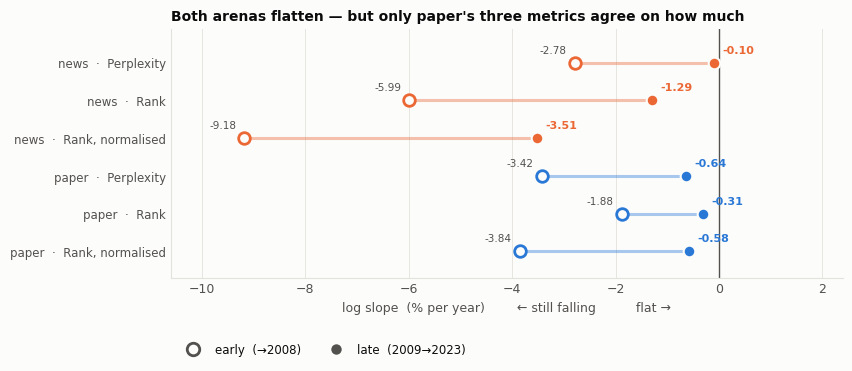

In [20]:
# ============ Fig 3 — slopes ============
START={"news":1998,"paper":1993}
def slope(d,col,a,b):
    m=(d.year>=a)&(d.year<=b); return np.polyfit(d.year[m],np.log(d[col][m]),1)[0]*100
rows=[]
for s in ["paper","news"]:
    for col,lab in [("rank_norm_median","Rank, normalised"),("rank_median","Rank"),("pp_median","Perplexity")]:
        d=S(s,6); rows.append((s,lab,slope(d,col,START[s],SPLIT),slope(d,col,SPLIT+1,2023)))
R=pd.DataFrame(rows,columns=["source","metric","early","late"])
fig,ax=plt.subplots(figsize=(8.6,3.9))
for k,(_,r) in enumerate(R.iterrows()):
    y=k
    ax.plot([r.early,r.late],[y,y],color=CLR[r.source],lw=2.2,alpha=.4,zorder=2,solid_capstyle="round")
    ax.scatter([r.early],[y],s=70,color=SURF,edgecolor=CLR[r.source],lw=2,zorder=3)
    ax.scatter([r.late],[y],s=70,color=CLR[r.source],edgecolor=SURF,lw=1.5,zorder=4)
    ax.annotate(f"{r.late:+.2f}",(r.late,y),xytext=(6,7),textcoords="offset points",
                fontsize=8,color=CLR[r.source],fontweight="bold")
    ax.annotate(f"{r.early:+.2f}",(r.early,y),xytext=(-6,7),textcoords="offset points",
                fontsize=7.5,color=INK2,ha="right")
ax.axvline(0,color=INK2,lw=1,zorder=1)
ax.set_yticks(range(len(R))); ax.set_yticklabels([f"{r.source}  ·  {r.metric}" for _,r in R.iterrows()],fontsize=8.5)
ax.set_ylim(-.7,len(R)-.1); ax.set_xlim(-10.6,2.4)
ax.set_xlabel("log slope  (% per year)        ← still falling          flat →")
ax.set_title("Both arenas flatten — but only paper's three metrics agree on how much",loc="left")
tidy(ax,ygrid=False)
ax.legend(handles=[Line2D([],[],marker="o",ls="",mfc=SURF,mec=INK2,mew=2,ms=9,label=f"early  (→{SPLIT})"),
                   Line2D([],[],marker="o",ls="",mfc=INK2,mec=SURF,mew=1.5,ms=9,label=f"late  ({SPLIT+1}→2023)")],
          loc="upper left",bbox_to_anchor=(0,-.22),ncol=2,fontsize=8.5)
plt.tight_layout(); plt.savefig(f"{FIG}/fig3_slopes.png",dpi=200); plt.show()

### 8.4 Figure 4

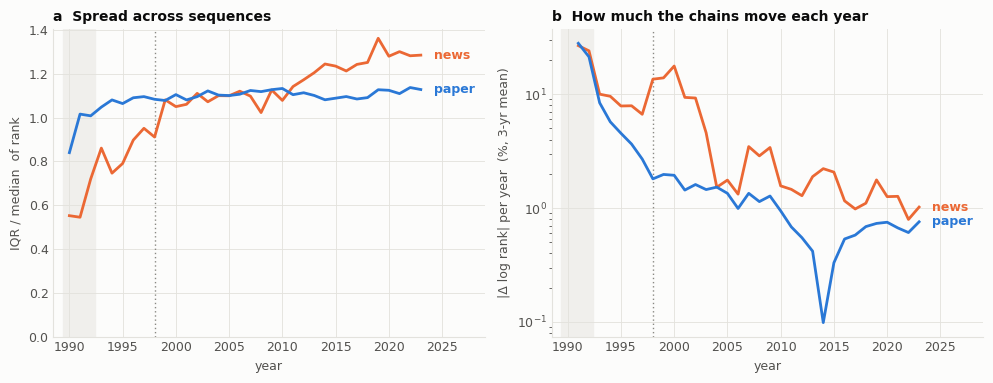

In [21]:
# ============ Fig 4 — dispersion & annual movement (scale-free) ============
fig,axes=plt.subplots(1,2,figsize=(10.0,3.9))
ax=axes[0]
for s in ["news","paper"]:
    d=S(s,6); rel=(d.rank_q75-d.rank_q25)/d.rank_median
    ax.plot(d.year,rel,color=CLR[s],lw=2,zorder=3)
    ax.annotate(s,(2024.2,rel.iloc[-1]),color=CLR[s],fontsize=9,fontweight="bold",va="center")
ax.axvspan(1989.4,1992.4,color=BAND,zorder=0); ax.axvline(1998,color=MUTED,ls=(0,(1,2)),lw=1)
ax.set_xlim(1988.5,2029); ax.set_ylim(0,None)
ax.set_xlabel("year"); ax.set_ylabel("IQR / median  of rank")
ax.set_title("a  Spread across sequences",loc="left"); tidy(ax)

ax=axes[1]
for s in ["news","paper"]:
    d=S(s,6).set_index("year")
    mv=np.abs(np.diff(np.log(d.rank_median)))
    yy=d.index[1:]; mv=pd.Series(mv,index=yy).rolling(3,center=True,min_periods=1).mean()
    ax.plot(yy,mv*100,color=CLR[s],lw=2,zorder=3)
    ax.annotate(s,(2024.2,mv.iloc[-1]*100),color=CLR[s],fontsize=9,fontweight="bold",va="center")
ax.axvspan(1989.4,1992.4,color=BAND,zorder=0); ax.axvline(1998,color=MUTED,ls=(0,(1,2)),lw=1)
ax.set_xlim(1988.5,2029); ax.set_yscale("log")
ax.set_xlabel("year"); ax.set_ylabel("|Δ log rank| per year  (%, 3-yr mean)")
ax.set_title("b  How much the chains move each year",loc="left"); tidy(ax)
plt.tight_layout(); plt.savefig(f"{FIG}/fig4_dispersion.png",dpi=200); plt.show()

## 9) 유사한 path를 선정, news/paper 양쪽으로 채점

두 코퍼스는 29,312개 어휘를 공유하므로 **같은 개념 연쇄를 news 모형과 paper 모형 양쪽에서
채점할 수 있다.** 연쇄가 서로 달라서 생기는 교란이 제거된 비교다.

절차: 양쪽 모두에서 L년 이상 지속된 개념(111개) → 두 코퍼스 34년 내내 활성인 것(39개)
→ 그 위에서 어느 한쪽이라도 지속 엣지인 관계를 따라 길이 5 연쇄 3,000개 생성
→ 두 모형으로 각각 채점.

In [22]:
K_COMMON = 5
NSEQ_COMMON = 3000

def pe(src):
    E={}
    with gzip.open(f"{BASE}/results/tables/{src}_edge_persistence.csv.gz",'rt') as fh:
        for x in csv.DictReader(fh):
            if int(x['longest_run'])>=L:
                i,j=int(x['i']),int(x['j']); E[(min(i,j),max(i,j))]=(int(x['run_start']),int(x['run_end']))
    return E
EN,EP=pe('news'),pe('paper')
common=set(i for e in EN for i in e)&set(i for e in EP for i in e)
EU={}
for E in (EN,EP):
    for e,v in E.items():
        if e[0] in common and e[1] in common:
            if e in EU: EU[e]=(min(EU[e][0],v[0]),max(EU[e][1],v[1]))
            else: EU[e]=v
adj=defaultdict(list)
for i,j in EU: adj[i].append(j); adj[j].append(i)
adj={k:np.array(v) for k,v in adj.items()}
print(f"공통 개념 {len(common)}, 공통풀 내 지속 엣지 {len(EU)}")

# 활성 여부 (두 코퍼스 모두 전 연도 활성인 개념만)
def active_years(src):
    A={}
    for t,yr in enumerate(range(1990,2024)):
        z=np.load(f"{BASE}/data/processed/networks_emb/{src}_{yr}_adj_f.npz",allow_pickle=True)
        A[yr]=np.diff(z['indptr'])>0
    return A
AN,AP=active_years('news'),active_years('paper')
alwaysN=np.all([AN[y] for y in AN],axis=0); alwaysP=np.all([AP[y] for y in AP],axis=0)
ok=set(np.where(alwaysN&alwaysP)[0])&common
print(f"양쪽 34년 내내 활성인 공통 개념 {len(ok)}")

K=K_COMMON
rng=np.random.default_rng(7); seqs={}
nd=np.array([n for n in adj if n in ok])
for _ in range(400000):
    s=int(rng.choice(nd)); path=[s]; seen={s}
    for _ in range(K-1):
        nb=[x for x in adj[path[-1]] if x in ok and x not in seen]
        if not nb: break
        path.append(int(nb[rng.integers(len(nb))])); seen.add(path[-1])
    if len(path)==K:
        key=tuple(path) if path[0]<path[-1] else tuple(reversed(path))
        seqs.setdefault(key,0); seqs[key]+=1
    if len(seqs)>=NSEQ_COMMON: break
S=np.array([list(k) for k in seqs])
print(f"공통 시퀀스 K={K}: {len(S)}개")

def load_pt(p,shape=(34,29312,32)):
    z=zipfile.ZipFile(p); n=[i.filename for i in z.infolist() if i.filename.endswith('data/0')][0]
    return np.frombuffer(z.read(n),dtype='<f4').reshape(shape)

res={}
for src in ['news','paper']:
    Emb=load_pt(f"{BASE}/data/processed/embeddings/{src}_embeddings.pt")
    RK=np.zeros((len(S),34))
    for t in range(34):
        yr=1990+t
        z=np.load(f"{BASE}/data/processed/networks_emb/{src}_{yr}_adj_f.npz",allow_pickle=True)
        act=np.where(np.diff(z['indptr'])>0)[0]; nA=len(act)
        remap=-np.ones(29312,dtype=np.int64); remap[act]=np.arange(nA)
        Z=Emb[t]; Za=np.ascontiguousarray(Z[act]); n=len(S)
        rk=np.zeros((n,K-1))
        for d,seq in enumerate([S,S[:,::-1]]):
            R=remap[seq]
            for k in range(1,K):
                w=LAM**np.arange(k-1,-1,-1); w=w/w.sum()
                C=(Z[seq[:,:k]]*w[None,:,None]).sum(1)
                acc=np.zeros(n)
                for s0 in range(0,n,1000):
                    s1=min(s0+1000,n); b=s1-s0
                    Lg=C[s0:s1]@Za.T
                    pr=R[s0:s1,:k]; rows=np.repeat(np.arange(b),k); cols=pr.ravel(); m=cols>=0
                    Lg[rows[m],cols[m]]=-np.inf
                    lg_t=Lg[np.arange(b),R[s0:s1,k]]
                    acc[s0:s1]=(Lg>lg_t[:,None]).sum(1)+1
                rk[:,k-1]=acc if d==0 else (rk[:,k-1]+acc)/2
        RK[:,t]=rk.mean(1)/nA          # 정규화 순위 (코퍼스 간 비교용)
        print(f"  {src} {yr}",end="\r",flush=True)
    res[src]=RK; del Emb
np.savez(f"{SEQ}/common_seq_K{K}.npz",S=S,news=res["news"],paper=res["paper"])
print("\n저장 완료")

공통 개념 111, 공통풀 내 지속 엣지 196
양쪽 34년 내내 활성인 공통 개념 39
공통 시퀀스 K=5: 3000개
  paper 2023
저장 완료


### 9.0 먼저 — 겹치는 구조가 얼마나 되나

**이 점검을 그림보다 먼저 돌릴 것.** 두 영역에서 모두 지속된 엣지가 몇 개인지,
그리고 비교용으로 만든 연쇄가 실제로 몇 개의 개념·엣지 위에 서 있는지 확인한다.
여기서 허브 쏠림이 확인되면 9.1–9.3의 결과는 그 한정 아래에서만 읽어야 한다.

In [23]:
import collections
vocab={}
_r=csv.DictReader(open(f"{BASE}/results/tables/backbone_vocab.csv")); _k=_r.fieldnames
for _x in _r: vocab[int(_x[_k[0]])]=_x[_k[1]]

EN,_=persistent_graph("news"); EP,_=persistent_graph("paper")
both=set(EN)&set(EP)
print(f"양쪽 모두 L>={L}년 지속된 엣지: {len(both)}개")
for i,j in sorted(both): print(f"   {vocab.get(i,i)}  —  {vocab.get(j,j)}")

def diversity(S, label):
    c=collections.Counter(S.ravel()); E=collections.Counter()
    for row in S:
        for a,b in zip(row[:-1],row[1:]): E[(min(a,b),max(a,b))]+=1
    top=c.most_common(3)
    print(f"\n{label}: 시퀀스 {len(S):,}  개념 {len(c):,}  엣지 {len(E):,}  "
          f"고유집합 {len(set(frozenset(r) for r in S)):,}")
    print("   상위3 개념 비중 "
          + ", ".join(f"{vocab.get(k,k)} {n/S.size:.1%}" for k,n in top))
    return c

for src in SOURCES:
    for K in KS:
        diversity(np.load(f"{SEQ}/seqs_{src}_K{K}.npz")["P"], f"본 분석 {src} K={K}")

양쪽 모두 L>=20년 지속된 엣지: 12개
   architecture  —  software
   automation  —  software
   data collection  —  software
   data processing  —  software
   interoperability  —  software
   medical imaging  —  software
   medical imaging  —  tomography
   project management  —  software
   software  —  systems design
   software  —  usability
   software  —  user interface
   software  —  visualization

본 분석 news K=6: 시퀀스 2,000  개념 569  엣지 1,794  고유집합 2,000
   상위3 개념 비중 automation 8.0%, software 5.9%, alliances 3.3%

본 분석 news K=8: 시퀀스 2,000  개념 577  엣지 1,808  고유집합 2,000
   상위3 개념 비중 automation 7.0%, software 5.6%, customer services 3.4%

본 분석 paper K=6: 시퀀스 2,000  개념 2,003  엣지 7,910  고유집합 2,000
   상위3 개념 비중 image (mathematics) 2.9%, control (management) 2.7%, process (computing) 1.9%

본 분석 paper K=8: 시퀀스 2,000  개념 2,173  엣지 10,102  고유집합 2,000
   상위3 개념 비중 control (management) 2.7%, image (mathematics) 2.4%, process (computing) 1.9%


### 9.1 중앙값 궤적과 기울기

In [24]:
d=np.load(f"{SEQ}/common_seq_K{K_COMMON}.npz"); S=d["S"]; RN=d["news"]; RP=d["paper"]
yrs=np.arange(1990,2024)
nA={s: np.array([(np.diff(np.load(f"{BASE}/data/processed/networks_emb/{s}_{y}_adj_f.npz",allow_pickle=True)["indptr"])>0).sum()
                 for y in yrs]) for s in SOURCES}
rawN, rawP = RN*nA["news"], RP*nA["paper"]
def sl(v,a,b):
    m=(yrs>=a)&(yrs<=b); return np.polyfit(yrs[m],np.log(v[m]),1)[0]*100
print("연도 |  news 순위  순위%  | paper 순위  순위%")
for t,y in enumerate(yrs):
    if y in (1993,1998,2003,2008,2013,2018,2023):
        print(f"{y} | {np.median(rawN[:,t]):8.0f} {np.median(RN[:,t])*100:6.2f}  |"
              f" {np.median(rawP[:,t]):8.0f} {np.median(RP[:,t])*100:6.2f}")
print()
for lab,v,st in [("news 순위",np.median(rawN,0),1998),("news 순위%",np.median(RN,0),1998),
                 ("paper 순위",np.median(rawP,0),1993),("paper 순위%",np.median(RP,0),1993)]:
    print(f"{lab:12} 전기 {sl(v,st,2008):+6.2f}  후기 {sl(v,2009,2023):+6.2f}")

연도 |  news 순위  순위%  | paper 순위  순위%
1993 |      188   7.99  |     1520  11.63
1998 |      168   3.87  |     1351   9.60
2003 |      120   2.49  |     1237   7.71
2008 |       98   1.59  |     1085   6.31
2013 |       90   1.52  |     1031   5.80
2018 |       93   1.32  |     1035   5.78
2023 |       95   1.25  |     1019   5.62

news 순위      전기  -3.96  후기  +0.29
news 순위%     전기  -7.15  후기  -1.93
paper 순위     전기  -1.87  후기  -0.32
paper 순위%    전기  -3.83  후기  -0.59


In [25]:
# 공통 연쇄가 실제로 몇 개 개념 위에 서 있나 — 해석 전 필수 점검
c=diversity(S, "공통 연쇄")
auto=[k for k,v in vocab.items() if v=="automation"][0]
soft=[k for k,v in vocab.items() if v=="software"][0]
hasA=np.array([auto in r for r in S]); hasS=np.array([soft in r for r in S])
print(f"   automation 포함 {hasA.mean():.1%} · software 포함 {hasS.mean():.1%} · "
      f"둘 다 {(hasA&hasS).mean():.1%} · 둘 다 없음 {(~hasA&~hasS).mean():.1%}")
print("\n→ 허브 쏠림이 크면 아래 그림의 사분위 범위·산점도를 독립 표본의 분포로 읽지 말 것.")


공통 연쇄: 시퀀스 3,000  개념 36  엣지 62  고유집합 2,143
   상위3 개념 비중 automation 19.3%, software 19.2%, cost control 4.1%
   automation 포함 96.5% · software 포함 96.2% · 둘 다 92.7% · 둘 다 없음 0.0%

→ 허브 쏠림이 크면 아래 그림의 사분위 범위·산점도를 독립 표본의 분포로 읽지 말 것.


### 9.2 Figure 5 · 6

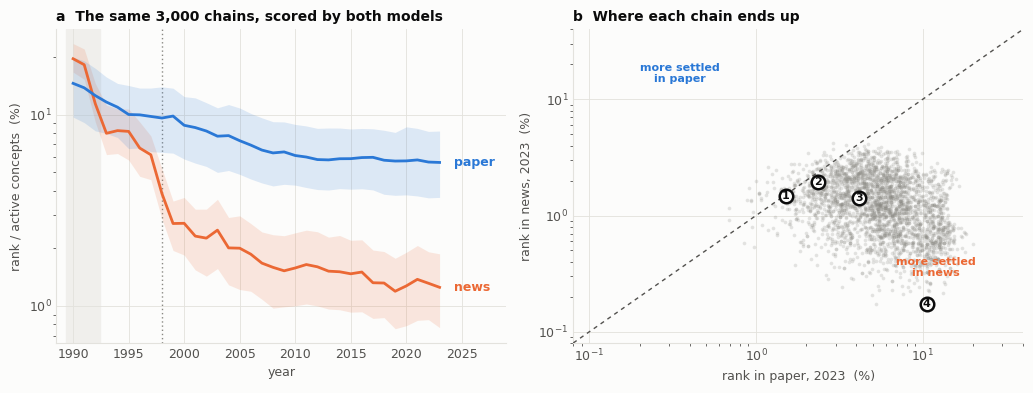

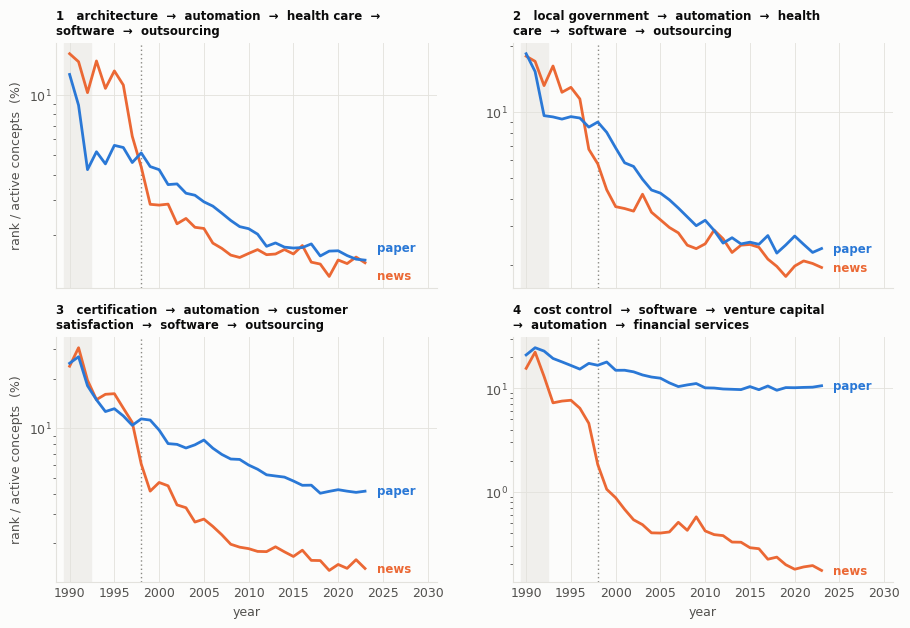

In [26]:
vocab={}
r=csv.DictReader(open(f"{BASE}/results/tables/backbone_vocab.csv")); ks=r.fieldnames
for x in r: vocab[int(x[ks[0]])]=x[ks[1]]

def nm(s, sep=" → "): return sep.join(vocab.get(int(v), str(v)) for v in s)
def V(x): return vocab.get(int(x), str(x))

# Fig 6에 실을 네 개의 대표 연쇄. 이름으로 지정하고 표본에서 위치를 찾는다.
PICKS = [("architecture → automation → health care → software → outsourcing", "converge"),
         ("local government → automation → health care → software → outsourcing", "converge"),
         ("certification → automation → customer satisfaction → software → outsourcing", "news first"),
         ("cost control → software → venture capital → automation → financial services", "diverge")]

def key(t):
    for j in range(len(S)):
        if nm(S[j]) == t: return j
    raise ValueError(f"PICKS에 적은 연쇄가 이번 표본에 없습니다: {t}")

idx = [key(t) for t, _ in PICKS]


RN=RN*100; RP=RP*100
# ---- Fig 5 ----
fig,axes=plt.subplots(1,2,figsize=(10.4,4.0))
ax=axes[0]
ax.axvspan(1989.4,1992.4,color=BAND,zorder=0); ax.axvline(1998,color=MUTED,ls=(0,(1,2)),lw=1)
for src,M in [("news",RN),("paper",RP)]:
    m=np.median(M,axis=0); q1=np.percentile(M,25,axis=0); q3=np.percentile(M,75,axis=0)
    ax.fill_between(yrs,q1,q3,color=CLR[src],alpha=.15,lw=0,zorder=2)
    ax.plot(yrs,m,color=CLR[src],lw=2,zorder=3)
    ax.annotate(src,(2024.3,m[-1]),color=CLR[src],fontsize=9,fontweight="bold",va="center")
ax.set_yscale("log"); ax.set_xlim(1988.5,2029); ax.set_xlabel("year")
ax.set_ylabel("rank / active concepts  (%)")
ax.set_title("a  The same 3,000 chains, scored by both models",loc="left"); tidy(ax)

ax=axes[1]
ax.scatter(RP[:,-1],RN[:,-1],s=7,color=MUTED,alpha=.22,lw=0,zorder=2)
lim=[0.08,40]
ax.plot(lim,lim,color=INK2,lw=1,ls=(0,(3,3)),zorder=3)
for k,i in enumerate(idx):
    ax.scatter([RP[i,-1]],[RN[i,-1]],s=95,color=SURF,edgecolor=INK,lw=1.8,zorder=5)
    ax.annotate(str(k+1),(RP[i,-1],RN[i,-1]),fontsize=8,fontweight="bold",ha="center",va="center",zorder=6)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel("rank in paper, 2023  (%)"); ax.set_ylabel("rank in news, 2023  (%)")
ax.text(12,.3,"more settled\nin news",fontsize=8,color=NEWS,ha="center",fontweight="bold")
ax.text(.35,14,"more settled\nin paper",fontsize=8,color=PAPER,ha="center",fontweight="bold")
ax.set_title("b  Where each chain ends up",loc="left"); tidy(ax)
plt.tight_layout(); plt.savefig(f"{FIG}/fig5_common.png",dpi=200); plt.show()


# ---- Fig 6 ----
import textwrap
fig,axes=plt.subplots(2,2,figsize=(10.8,7.0),sharex=True)
for ax,(title,tag),i,k in zip(axes.ravel(),PICKS,idx,range(1,5)):
    ax.axvspan(1989.4,1992.4,color=BAND,zorder=0); ax.axvline(1998,color=MUTED,ls=(0,(1,2)),lw=1)
    ends=[("news",RN[i,-1]),("paper",RP[i,-1])]
    ends.sort(key=lambda x:x[1])
    for rank_i,(src,val) in enumerate(ends):
        M=RN if src=="news" else RP
        ax.plot(yrs,M[i],color=CLR[src],lw=2,zorder=3)
    sep = abs(np.log10(ends[0][1])-np.log10(ends[1][1])) < .08
    for rank_i,(src,val) in enumerate(ends):
        dy = (-9 if rank_i==0 else 9) if sep else 0
        ax.annotate(src,(2024.3,val),xytext=(0,dy),textcoords="offset points",
                    color=CLR[src],fontsize=8.5,fontweight="bold",va="center")
    ax.set_yscale("log"); ax.set_xlim(1988.5,2031)
    ax.set_title(str(k)+"   "+textwrap.fill(title.replace(" \u2192 ","  \u2192  "),46),
                 loc="left",fontsize=8.5,color=INK,pad=6)
    tidy(ax)
for ax in axes[1]: ax.set_xlabel("year")
for ax in axes[:,0]: ax.set_ylabel("rank / active concepts  (%)")


### 9.3 대표 시퀀스 표

각 코퍼스 자기 연쇄의 대표 사례와, 공통 연쇄의 수렴/분기 사례를
`example_sequences.csv`로 저장한다.

In [27]:
def nm2(s): return " -> ".join(vocab.get(int(v),str(v)) for v in s)
def sls(M,a,b):
    m=(yrs>=a)&(yrs<=b); X=yrs[m]-yrs[m].mean()
    return (np.log(M[:,m])*X).sum(1)/(X**2).sum()*100
rows=[]
for src in SOURCES:
    Pn=np.load(f"{SEQ}/seqs_{src}_K6.npz")["P"]
    dd=df[(df.source==src)&(df.K==6)].pivot_table(index="seq_id",columns="year",values="rank")
    a,b=dd[1995],dd[2023]
    for lab,ids in [("most settled 2023",b.nsmallest(3).index),
                    ("largest drop",(b/a).nsmallest(3).index),
                    ("did not settle",(b/a).nlargest(2).index)]:
        for i in ids: rows.append(("own",src,lab,nm2(Pn[i]),round(a[i]),round(b[i]),"","",""))
slN,slP=sls(RN,2009,2023),sls(RP,2009,2023)
sc=(RN[:,-1]/RN[:,5])+(RP[:,-1]/RP[:,5]); dif=slP-slN
for lab,ids in [("both settle",np.argsort(sc)[:4]),
                ("news settles, paper does not",np.argsort(-dif)[:4]),
                ("paper settles, news does not",np.argsort(dif)[:4])]:
    for i in ids:
        rows.append(("shared","both",lab,nm2(S[i]),"","",
                     f"{RN[i,5]:.2f}->{RN[i,-1]:.2f}",f"{RP[i,5]:.2f}->{RP[i,-1]:.2f}",
                     f"news {slN[i]:+.2f} / paper {slP[i]:+.2f}"))
ex=pd.DataFrame(rows,columns=["set","corpus","category","sequence","rank_1995","rank_2023",
                              "news_rank_pct","paper_rank_pct","late_slope"])
ex.to_csv(f"{SEQ}/example_sequences.csv",index=False)
ex[ex.set=="shared"][["category","sequence","news_rank_pct","paper_rank_pct"]]

,category,sequence,news_rank_pct,paper_rank_pct
16,both settle,architecture -> automation -> health care -> s...,13.14->1.46,5.60->1.51
17,both settle,architecture -> software -> health care -> aut...,13.14->1.46,5.60->1.51
18,both settle,local government -> automation -> health care ...,12.93->1.94,9.50->2.37
19,both settle,certification -> automation -> customer satisf...,16.18->1.41,13.12->4.15
20,"news settles, paper does not",cost control -> software -> venture capital ->...,7.68->0.17,16.65->10.60
21,"news settles, paper does not",cost control -> manufacturing -> automation ->...,7.00->0.22,16.00->10.84
22,"news settles, paper does not",certification -> software -> venture capital -...,13.93->0.32,12.21->7.27
23,"news settles, paper does not",automation -> venture capital -> software -> c...,7.31->0.26,19.82->13.66
24,"paper settles, news does not",cost reduction -> software -> security managem...,2.84->0.65,20.90->13.93
25,"paper settles, news does not",information management -> software -> cost red...,4.99->0.74,19.38->11.09


## 10) 의미가 대응하는 연쇄 — 어휘가 달라도 같은 자리

9절은 어휘가 **완전히 같은** 연쇄만 다루었는데, 여기서는 **워딩이 달라도 쓰이는 맥락이 같으면 같은 자리로 본다.**

두 코퍼스가 어휘를 공유하므로, 각 개념의 **공출현 프로필**(34년 합산 → PPMI → L2)을
공통 특징 차원 위에서 만들고 코사인으로 비교한다. 허위 대응을 막기 위해
(a) 상호 최근접(양방향 상위 R위 이내), (b) 다의어 허브 제외(지속망 연결선수 ≥ 100)를 건다.

### 10.1 코퍼스 간 개념 유사도

In [29]:
def csr(src,yr):
    z=np.load(f"{BASE}/data/processed/networks_emb/{src}_{yr}_adj_f.npz",allow_pickle=True)
    return z['data'],z['indices'],z['indptr']

# 1) 특징 공간: 두 코퍼스 모두에서 자주 등장하는 개념
degsum={}
for src in ['news','paper']:
    acc=np.zeros(N_NODE)
    for yr in YEARS:
        d,i,p=csr(src,yr); acc+=np.add.reduceat(np.r_[d,0],p[:-1])*(np.diff(p)>0)
    degsum[src]=acc
both_active=(degsum['news']>0)&(degsum['paper']>0)
print("두 코퍼스 모두 등장한 개념:", both_active.sum())
feat=np.where(both_active)[0]
fmap=-np.ones(N_NODE,dtype=np.int64); fmap[feat]=np.arange(len(feat))
print("특징 차원:", len(feat))

# 2) 관심 개념 (표본 시퀀스에 등장한 것)
targ={s:sorted(set(np.load(f"{SEQ}/seqs_{s}_K6.npz")['P'].ravel().tolist())) for s in ['news','paper']}
print("개념 수  news", len(targ['news']), " paper", len(targ['paper']))

# 3) 공출현 프로필 (34년 합산) → PPMI → L2
def profiles(src, nodes):
    idx={n:k for k,n in enumerate(nodes)}
    M=np.zeros((len(nodes),len(feat)),dtype=np.float32)
    for yr in YEARS:
        d,i,p=csr(src,yr)
        for n in nodes:
            sl=slice(p[n],p[n+1])
            if sl.stop<=sl.start: continue
            cols=fmap[i[sl]]; m=cols>=0
            np.add.at(M[idx[n]],cols[m],d[sl][m])
    tot=M.sum()
    rw=M.sum(1,keepdims=True); cw=M.sum(0,keepdims=True)
    with np.errstate(divide='ignore',invalid='ignore'):
        P=np.log(np.maximum(M*tot,1e-12)/np.maximum(rw*cw,1e-12))
    P[~np.isfinite(P)]=0; P=np.maximum(P,0)          # PPMI
    P/= (np.linalg.norm(P,axis=1,keepdims=True)+1e-9)
    return P
PN=profiles('news',targ['news']); PP=profiles('paper',targ['paper'])
SIM=PN@PP.T                                            # [569, 2003] 코사인
np.savez(f"{SEQ}/concept_match.npz",news=np.array(targ['news']),paper=np.array(targ['paper']),SIM=SIM)
print("유사도 행렬",SIM.shape,"중앙값",np.median(SIM).round(3))
ii,jj=np.unravel_index(np.argsort(-SIM,axis=None)[:250],SIM.shape)
seen=set()
for a,b in zip(ii,jj):
    na,nb=targ["news"][a],targ["paper"][b]
    if na==nb or na in seen: continue
    seen.add(na); print(f"   {SIM[a,b]:.3f}   {vocab.get(na,na):34s} ~ {vocab.get(nb,nb)}")
    if len(seen)>=12: break

TypeError: expected a sequence of integers or a single integer, got '{(1827, 24651): (1990, 2023), (1827, 6503): (1990, 2023), (755, 1827): (1990, 2023), (22850, 22851):'

### 10.2 전부 대 전부 — 가장 유사한 시퀀스 쌍

제약을 두지 않는다. news 지속 시퀀스 2,000개 × paper 지속 시퀀스 2,000개를 전부 비교한다.

- **동일한 개념은 유사도 1.0** — 같은 개념은 최대 유사이므로 순위 검정으로 걸러서는 안 된다.
- 시퀀스 유사도 = 자리별 유사도의 **기하평균**. 산술평균이면 동일 개념 한 자리(1.0)가
  나머지 자리의 부실을 가린다.
- 무방향이므로 정·역 정렬 중 큰 쪽.

궤적은 이미 §5에서 계산해 두었으므로 재채점이 필요 없다.

In [ ]:
z=np.load(f"{SEQ}/concept_match.npz"); NN=z['news']; PPn=z['paper']; SIM=z['SIM'].copy()
ni={n:k for k,n in enumerate(NN)}; pi={n:k for k,n in enumerate(PPn)}
for v,a in ni.items():
    b=pi.get(v)
    if b is not None: SIM[a,b]=1.0
K=6
SN=np.load(f"{SEQ}/seqs_news_K{K}.npz")['P']; SP=np.load(f"{SEQ}/seqs_paper_K{K}.npz")['P']
A=np.array([[ni[v] for v in r] for r in SN]); B=np.array([[pi[v] for v in r] for r in SP])
def sc(Bm):
    t=np.zeros((len(A),len(B)),np.float32); mn=np.full((len(A),len(B)),9,np.float32)
    for k in range(K):
        v=SIM[np.ix_(A[:,k],Bm[:,k])]; t+=np.log(np.maximum(v,1e-3)); np.minimum(mn,v,out=mn)
    return np.exp(t/K), mn
f,fm=sc(B); r_,rm=sc(B[:,::-1]); rev=r_>f
S=np.where(rev,r_,f); MN=np.where(rev,rm,fm)
dn=pd.read_csv(f"{SEQ}/seq_news_K{K}.csv").pivot_table(index='seq_id',columns='year',values='rank_norm')*100
dp=pd.read_csv(f"{SEQ}/seq_paper_K{K}.csv").pivot_table(index='seq_id',columns='year',values='rank_norm')*100
yrs=np.arange(1990,2024)
nA={s:np.array([(np.diff(np.load(f"{BASE}/data/processed/networks_emb/{s}_{y}_adj_f.npz",allow_pickle=True)['indptr'])>0).sum() for y in yrs]) for s in ['news','paper']}
order=np.argsort(-S,axis=None); usedN=set(); usedP=set(); rows=[]
setN=[set(x.tolist()) for x in SN]; setP=[set(x.tolist()) for x in SP]
for o in order:
    a,b=np.unravel_index(o,S.shape)
    if a in usedN or b in usedP: continue
    if dn.loc[a].isna().any() or dp.loc[b].isna().any(): continue
    usedN.add(a); usedP.add(b)
    rows.append((int(a),int(b),float(S[a,b]),float(MN[a,b]),len(setN[a]&setP[b]),bool(rev[a,b])))
    if len(rows)>=8: break
out=[]
for k,(a,b,s,mn,ov,rv) in enumerate(rows,1):
    ns=SN[a]; ps=SP[b][::-1] if rv else SP[b]
    n=dn.loc[a].values; p=dp.loc[b].values
    nr=n/100*nA['news']; pr=p/100*nA['paper']
    print(f"\n━━━ [{k}] 기하평균 {s:.3f}  최소자리 {mn:.2f}  동일 개념 {ov}/{K}")
    for x,y in zip(ns,ps):
        mk="=" if int(x)==int(y) else "~"
        print(f"      {V(x):34s} {mk} {V(y):38s} {SIM[ni[int(x)],pi[int(y)]]:.2f}")
    print(f"   news   1995 {n[5]:6.2f}%  2023 {n[-1]:5.2f}%   후기 {sl(n,2009,2023):+.2f}%/년 (원순위 {sl(nr,2009,2023):+.2f})")
    print(f"   paper  1995 {p[5]:6.2f}%  2023 {p[-1]:5.2f}%   후기 {sl(p,2009,2023):+.2f}%/년 (원순위 {sl(pr,2009,2023):+.2f})")
    out.append([k,round(s,3),round(mn,3),ov,
        " -> ".join(V(x) for x in ns)," -> ".join(V(x) for x in ps),
        " | ".join(f"{V(x)} {'=' if int(x)==int(y) else '~'} {V(y)} ({SIM[ni[int(x)],pi[int(y)]]:.2f})" for x,y in zip(ns,ps)),
        round(n[5],2),round(n[-1],2),round(p[5],2),round(p[-1],2),
        round(sl(n,2009,2023),2),round(sl(p,2009,2023),2),
        round(sl(nr,2009,2023),2),round(sl(pr,2009,2023),2)])
with open(f"{SEQ}/matched_sequences.csv","w",newline="") as fh:
    w=csv.writer(fh); w.writerow(["id","geomean_sim","min_position_sim","identical_concepts",
      "news_sequence","paper_sequence","position_pairs","news_pct_1995","news_pct_2023",
      "paper_pct_1995","paper_pct_2023","news_late_slope_pct","paper_late_slope_pct",
      "news_late_slope_raw","paper_late_slope_raw"]); w.writerows(out)
np.savez(f"{SEQ}/matched_final.npz",news_idx=np.array([r[0] for r in rows]),
         paper_idx=np.array([r[1] for r in rows]),rev=np.array([r[5] for r in rows]),
         score=np.array([r[2] for r in rows]),overlap=np.array([r[4] for r in rows]))
nn=np.array([o[13] for o in out]); pp=np.array([o[14] for o in out])


### 10.3 Figure 7

In [ ]:
m=np.load(f"{SEQ}/matched_final.npz")
NI,PI,RV,SCq,OV=m["news_idx"],m["paper_idx"],m["rev"],m["score"],m["overlap"]
SN=np.load(f"{SEQ}/seqs_news_K6.npz")['P']; SP=np.load(f"{SEQ}/seqs_paper_K6.npz")['P']
dn=pd.read_csv(f"{SEQ}/seq_news_K6.csv").pivot_table(index='seq_id',columns='year',values='rank_norm')*100
dp=pd.read_csv(f"{SEQ}/seq_paper_K6.csv").pivot_table(index='seq_id',columns='year',values='rank_norm')*100
yrs=np.arange(1990,2024)
LAB=["Education & IT","Computing education","Education & robotics","Robotics research",
     "Employment & IT","Finance","AI & education","Health care"]
PICK=[0,1,3,4,5,7]
fig,axes=plt.subplots(2,3,figsize=(14.6,8.4),sharex=True)
for ax,k in zip(axes.ravel(),PICK):
    a,b=int(NI[k]),int(PI[k])
    ns=SN[a]; ps=SP[b][::-1] if RV[k] else SP[b]
    ax.axvspan(1989.4,1992.4,color=BAND,zorder=0); ax.axvline(1998,color=MUTED,ls=(0,(1,2)),lw=1)
    n=dn.loc[a].values; p=dp.loc[b].values
    ax.plot(yrs,n,color=NEWS,lw=2,zorder=3); ax.plot(yrs,p,color=PAPER,lw=2,zorder=3)
    ends=sorted([("news",n[-1],NEWS),("paper",p[-1],PAPER)],key=lambda t:t[1])
    close=abs(np.log10(ends[0][1])-np.log10(ends[1][1]))<.09
    for r_,(lab,val,c) in enumerate(ends):
        ax.annotate(lab,(2024.2,val),xytext=(0,(-9 if r_==0 else 9) if close else 0),
                    textcoords="offset points",color=c,fontsize=8.5,fontweight="bold",va="center")
    ax.set_yscale("log"); ax.set_xlim(1988.5,2031)
    ax.grid(True,alpha=.9,lw=.7); ax.set_axisbelow(True); ax.tick_params(length=0)
    nt=textwrap.fill(" → ".join(V(x) for x in ns),54)
    pt=textwrap.fill(" → ".join(V(x) for x in ps),54)
    nl=nt.count("\n")+1; pl=pt.count("\n")+1
    ax.text(0,1.012,pt,transform=ax.transAxes,fontsize=7.6,color=PAPER,va="bottom")
    ax.text(0,1.012+.062*pl,nt,transform=ax.transAxes,fontsize=7.6,color=NEWS,va="bottom")
    ax.text(0,1.020+.062*(pl+nl),f"{LAB[k]}   ·   sim {SCq[k]:.2f}, identical {int(OV[k])}/6",
            transform=ax.transAxes,fontsize=9.8,fontweight="bold",color=INK,va="bottom")
for ax in axes[1]: ax.set_xlabel("year")
for ax in axes[:,0]: ax.set_ylabel("rank / active concepts  (%)")
plt.tight_layout(h_pad=7.0,w_pad=2.2,rect=[0,0,1,.95])
plt.savefig(f"{FIG}/fig7_matched.png",dpi=200,bbox_inches="tight"); plt.show()